In [1]:
!pip install torch torchvision ultralytics pandas requests tqdm pyyaml matplotlib seaborn opencv-python scipy gitpython

Using cache found in C:\Users\NEW/.cache\torch\hub\ultralytics_yolov5_master


YOLOv5  2026-9-29 Python-3.11.15 torch-2.14.0+cpu CPU

Fusing layers... 
YOLOv5s summary: 124 layers, 7,225,885 parameters, 0 gradients, 16.4 GFLOPs
Adding AutoShape... 
image 1/1: 720x1280 2 persons, 1 tie
Speed: 1374.9ms pre-process, 77.7ms inference, 1.4ms NMS per image at shape (1, 3, 384, 640)
         xmin        ymin         xmax        ymax  confidence  class    name
0  745.563477   48.423248  1142.764282  720.000000    0.869361      0  person
1  124.165344  197.314484   842.481995  716.561035    0.627424      0  person
2  441.338074  439.451782   498.282227  708.494385    0.615022     27     tie


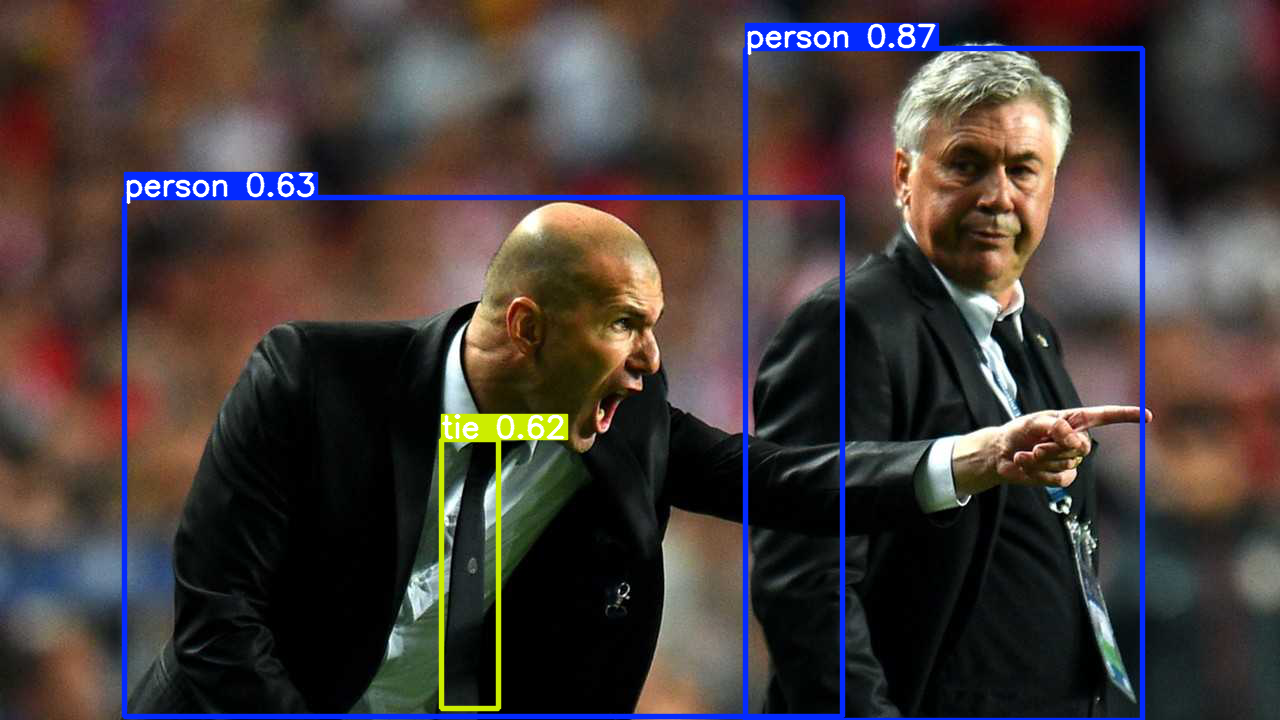

In [2]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"    

import torch
from PIL import Image
from IPython.display import display

model = torch.hub.load('ultralytics/yolov5', 'yolov5s', pretrained=True)
model.conf = 0.4

img = 'https://ultralytics.com/images/zidane.jpg'   

results = model(img)
results.print()
print(results.pandas().xyxy[0])


display(Image.fromarray(results.render()[0]))

In [3]:
import torch
from PIL import Image
from torchvision import transforms, models

def preprocess_for_resnet(image_path):
    image = Image.open(image_path).convert("RGB")
    transform = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])
    return transform(image).unsqueeze(0)   


weights = models.ResNet50_Weights.DEFAULT
model = models.resnet50(weights=weights)
model.eval()

x = preprocess_for_resnet("test.jpg")      
print("Input shape:", x.shape)

with torch.no_grad():
    probs = torch.softmax(model(x), dim=1)[0]

top5 = torch.topk(probs, 5)
for p, idx in zip(top5.values, top5.indices):
    print(f"{weights.meta['categories'][idx]}: {p.item():.3f}")

Input shape: torch.Size([1, 3, 224, 224])
kite: 0.108
white stork: 0.054
vulture: 0.050
bee eater: 0.034
bald eagle: 0.030


In [4]:
from PIL import Image
import numpy as np

Image.fromarray((np.random.rand(300, 300, 3) * 255).astype("uint8")).save("test.jpg")

In [5]:
import tensorflow as tf
from tensorflow.keras import layers, models


(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0


model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),

    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(x_train, y_train, epochs=10, batch_size=64, validation_split=0.1)

loss, acc = model.evaluate(x_test, y_test)
print(f"Test Accuracy: {acc:.4f}")

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 30s 40ms/step - accuracy: 0.3914 - loss: 1.6887 - val_accuracy: 0.4668 - val_loss: 1.5067
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 29s 41ms/step - accuracy: 0.5410 - loss: 1.2839 - val_accuracy: 0.5720 - val_loss: 1.1488
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 28s 40ms/step - accuracy: 0.6118 - loss: 1.1018 - val_accuracy: 0.6602 - val_loss: 0.9639
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 28s 40ms/step - accuracy: 0.6606 - loss: 0.9761 - val_accuracy: 0.6412 - val_loss: 1.0230
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 28s 40ms/step - accuracy: 0.6925 - loss: 0.8857 - val_accuracy: 0.7106 - val_loss: 0.8722
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 29s 41ms/step - accuracy: 0.7178 - loss: 0.8093 - val_accuracy: 0.6828 - val_loss: 0.9353
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 29s 41ms/step - accuracy: 0.7453 - loss: 0.7368 - val_accuracy: 0.7268 - val_loss: 0.8116
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 29s 42ms/step - accuracy: 0.7614 - loss: 0.6890 - 

In [6]:
import tensorflow as tf
from tensorflow.keras import layers, models

IMG_SIZE = (128, 128)

train_ds = tf.keras.utils.image_dataset_from_directory(
    "dataset", validation_split=0.2, subset="training", seed=123,
    image_size=IMG_SIZE, batch_size=32, label_mode="binary")
val_ds = tf.keras.utils.image_dataset_from_directory(
    "dataset", validation_split=0.2, subset="validation", seed=123,
    image_size=IMG_SIZE, batch_size=32, label_mode="binary")

print(train_ds.class_names)   

model = models.Sequential([
    layers.Input(shape=(128, 128, 3)),
    layers.Rescaling(1./255),                
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.fit(train_ds, validation_data=val_ds, epochs=10)

model.save("mask_detector.h5")

Found 3846 files belonging to 2 classes.
Using 3077 files for training.
Found 3846 files belonging to 2 classes.
Using 769 files for validation.
['with_mask', 'without_mask']
Epoch 1/10
97/97 ━━━━━━━━━━━━━━━━━━━━ 18s 179ms/step - accuracy: 0.8271 - loss: 0.3514 - val_accuracy: 0.9272 - val_loss: 0.1906
Epoch 2/10
97/97 ━━━━━━━━━━━━━━━━━━━━ 17s 179ms/step - accuracy: 0.9217 - loss: 0.2085 - val_accuracy: 0.9480 - val_loss: 0.1510
Epoch 3/10
97/97 ━━━━━━━━━━━━━━━━━━━━ 18s 182ms/step - accuracy: 0.9418 - loss: 0.1582 - val_accuracy: 0.9207 - val_loss: 0.1808
Epoch 4/10
97/97 ━━━━━━━━━━━━━━━━━━━━ 17s 178ms/step - accuracy: 0.9457 - loss: 0.1461 - val_accuracy: 0.9532 - val_loss: 0.1231
Epoch 5/10
97/97 ━━━━━━━━━━━━━━━━━━━━ 17s 177ms/step - accuracy: 0.9513 - loss: 0.1234 - val_accuracy: 0.9623 - val_loss: 0.0974
Epoch 6/10
97/97 ━━━━━━━━━━━━━━━━━━━━ 18s 181ms/step - accuracy: 0.9633 - loss: 0.1050 - val_accuracy: 0.9649 - val_loss: 0.1015
Epoch 7/10
97/97 ━━━━━━━━━━━━━━━━━━━━ 17s 175ms/ste

In [7]:
#import zipfile

#with zipfile.ZipFile("dataset-20260930T021833Z-1-001.zip", "r") as z:
   # z.extractall(".")

#import os
#print(os.listdir("."))

In [8]:
#import os

#def find_dataset(root="."):
   # for r, dirs, files in os.walk(root):
       # if "with_mask" in dirs and "without_mask" in dirs:
        #    return r
  #  return None

#DATA_DIR = find_dataset(".")
#print("DATA_DIR =", DATA_DIR)

#for name in os.listdir(DATA_DIR):
   # print(name, "->", len(os.listdir(os.path.join(DATA_DIR, name))), "items")

In [9]:
#import os
#os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

#import tensorflow as tf
#from tensorflow.keras import layers, models

#IMG_SIZE = (128, 128)

#train_ds = tf.keras.utils.image_dataset_from_directory(
 #   DATA_DIR, validation_split=0.2, subset="training", seed=123,
  #  image_size=IMG_SIZE, batch_size=32, label_mode="binary")
#val_ds = tf.keras.utils.image_dataset_from_directory(
 #   DATA_DIR, validation_split=0.2, subset="validation", seed=123,
  #  image_size=IMG_SIZE, batch_size=32, label_mode="binary")

#print(train_ds.class_names)   # ['with_mask', 'without_mask'] -> with_mask=0, without_mask=1

#model = models.Sequential([
 #   layers.Input(shape=(128, 128, 3)),
  #  layers.Rescaling(1./255),
   # layers.Conv2D(32, (3, 3), activation='relu'),
    #layers.MaxPooling2D(),
    #layers.Conv2D(64, (3, 3), activation='relu'),
    #layers.MaxPooling2D(),
    #layers.Conv2D(128, (3, 3), activation='relu'),
    #layers.MaxPooling2D(),
    #layers.Flatten(),
    #layers.Dropout(0.5),
    #layers.Dense(128, activation='relu'),
    #ayers.Dense(1, activation='sigmoid')
#])

#model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
#model.fit(train_ds, validation_data=val_ds, epochs=10)

#model.save("mask_detector.h5")
#print("Saved mask_detector.h5")

In [10]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import cv2
import numpy as np
import tensorflow as tf

# Load the trained model
model = tf.keras.models.load_model("mask_detector.h5")

# Face detector (comes bundled with OpenCV)
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml")

cap = cv2.VideoCapture(0)     # 0 = default webcam
if not cap.isOpened():
    raise RuntimeError("Could not open the webcam. Close other apps using it, or try VideoCapture(1).")

while True:
    ret, frame = cap.read()
    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(60, 60))

    for (x, y, w, h) in faces:
        face = frame[y:y+h, x:x+w]
        face = cv2.cvtColor(face, cv2.COLOR_BGR2RGB)      # OpenCV is BGR, the model was trained on RGB
        face = cv2.resize(face, (128, 128))
        face = np.expand_dims(face.astype("float32"), axis=0)   # shape (1, 128, 128, 3); scaling is inside the model

        pred = model.predict(face, verbose=0)[0][0]       # probability of "without_mask"

        if pred < 0.5:
            label, color, conf = "Mask", (0, 255, 0), 1 - pred
        else:
            label, color, conf = "No Mask", (0, 0, 255), pred

        cv2.rectangle(frame, (x, y), (x+w, y+h), color, 2)
        cv2.putText(frame, f"{label} {conf*100:.1f}%", (x, y-10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)

    cv2.imshow("Face Mask Detector", frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):                 # press q to quit
        break

cap.release()
cv2.destroyAllWindows()

In [ ]:
#import cv2
#print(cv2.__file__)
#print(getattr(cv2, "__version__", "no version"))

In [ ]:
#!pip uninstall -y opencv-python opencv-python-headless opencv-contrib-python
#!pip install opencv-python

In [ ]:
#import cv2
#print(cv2.__version__)
#print(hasattr(cv2, "CascadeClassifier"))

In [ ]:
#import sys
#3!{sys.executable} -m pip uninstall -y opencv-python opencv-python-headless opencv-contrib-python{sys.executable} -m pip install "opencv-python<5"

In [ ]:
#import cv2
#print(cv2.__version__)                     
#3print(hasattr(cv2, "CascadeClassifier"))    rint(cv2.data.haarcascades)   

In [ ]:
#import sys, cv2
#print("Notebook Python:", sys.executable)
#rint("cv2 loaded from:", cv2.__file__)
#rint("cv2 version:", cv2.__version__)
#print([n for n in dir(cv2) if "ascade" in n])   # any cascade-related names

In [ ]:
#!{sys.executable} -m pip list 2>NUL | findstr /i opencv

In [ ]:
#import sys
#!{sys.executable} -c "import cv2; print(cv2.__version__, hasattr(cv2, 'CascadeClassifier'))"

In [ ]:
#import cv2
#print(cv2.__version__, hasattr(cv2, "CascadeClassifier"))

In [ ]:
#import sys
#!{sys.executable} -m pip uninstall -y opencv-python opencv-python-headless opencv-contrib-python

In [11]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.optimizers import Adam

train_ds = tf.keras.utils.image_dataset_from_directory(
    "data/train", image_size=(224, 224), batch_size=32, label_mode="binary")
val_ds = tf.keras.utils.image_dataset_from_directory(
    "data/val", image_size=(224, 224), batch_size=32, label_mode="binary")

train_ds = train_ds.map(lambda x, y: (preprocess_input(x), y))
val_ds = val_ds.map(lambda x, y: (preprocess_input(x), y))

base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_model.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)         
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(128, activation='relu')(x)
outputs = layers.Dense(1, activation='sigmoid')(x)
model = tf.keras.Model(inputs, outputs)

model.compile(optimizer=Adam(1e-3), loss='binary_crossentropy', metrics=['accuracy'])
model.fit(train_ds, validation_data=val_ds, epochs=5)

base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

print("Trainable layers in base:", sum(l.trainable for l in base_model.layers))

model.compile(optimizer=Adam(1e-5),            
              loss='binary_crossentropy', metrics=['accuracy'])
model.fit(train_ds, validation_data=val_ds, epochs=5)

loss, acc = model.evaluate(val_ds)
print(f"Validation Accuracy: {acc:.4f}")

FileNotFoundError: [WinError 3] The system cannot find the path specified: 'data/train'

In [12]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.optimizers import Adam

def find_dataset(root="."):
    for r, dirs, files in os.walk(root):
        if "with_mask" in dirs and "without_mask" in dirs:
            return r
    return None

DATA_DIR = find_dataset(".")
print("DATA_DIR =", DATA_DIR)

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR, validation_split=0.2, subset="training", seed=123,
    image_size=(224, 224), batch_size=32, label_mode="binary")
val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR, validation_split=0.2, subset="validation", seed=123,
    image_size=(224, 224), batch_size=32, label_mode="binary")

train_ds = train_ds.map(lambda x, y: (preprocess_input(x), y))
val_ds = val_ds.map(lambda x, y: (preprocess_input(x), y))

base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_model.trainable = False


inputs = tf.keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)       # keeps BatchNorm layers in inference mode
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(128, activation='relu')(x)
outputs = layers.Dense(1, activation='sigmoid')(x)
model = tf.keras.Model(inputs, outputs)

model.compile(optimizer=Adam(1e-3), loss='binary_crossentropy', metrics=['accuracy'])
model.fit(train_ds, validation_data=val_ds, epochs=5)

base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

print("Trainable layers in base:", sum(l.trainable for l in base_model.layers))

model.compile(optimizer=Adam(1e-5),         
              loss='binary_crossentropy', metrics=['accuracy'])
model.fit(train_ds, validation_data=val_ds, epochs=5)

loss, acc = model.evaluate(val_ds)
print(f"Validation Accuracy: {acc:.4f}")

DATA_DIR = .\dataset
Found 3846 files belonging to 2 classes.
Using 3077 files for training.
Found 3846 files belonging to 2 classes.
Using 769 files for validation.
Epoch 1/5
97/97 ━━━━━━━━━━━━━━━━━━━━ 59s 575ms/step - accuracy: 0.9708 - loss: 0.0807 - val_accuracy: 0.9948 - val_loss: 0.0273
Epoch 2/5
97/97 ━━━━━━━━━━━━━━━━━━━━ 55s 564ms/step - accuracy: 0.9932 - loss: 0.0195 - val_accuracy: 0.9883 - val_loss: 0.0254
Epoch 3/5
97/97 ━━━━━━━━━━━━━━━━━━━━ 56s 571ms/step - accuracy: 0.9945 - loss: 0.0178 - val_accuracy: 0.9922 - val_loss: 0.0181
Epoch 4/5
97/97 ━━━━━━━━━━━━━━━━━━━━ 57s 583ms/step - accuracy: 0.9968 - loss: 0.0099 - val_accuracy: 0.9948 - val_loss: 0.0184
Epoch 5/5
97/97 ━━━━━━━━━━━━━━━━━━━━ 56s 578ms/step - accuracy: 0.9971 - loss: 0.0088 - val_accuracy: 0.9948 - val_loss: 0.0201
Trainable layers in base: 30
Epoch 1/5
97/97 ━━━━━━━━━━━━━━━━━━━━ 74s 692ms/step - accuracy: 0.9454 - loss: 0.1453 - val_accuracy: 0.9948 - val_loss: 0.0177
Epoch 2/5
97/97 ━━━━━━━━━━━━━━━━━━━━ 